In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [16]:
iris = load_iris()

In [17]:
x = iris.data

In [18]:
df = pd.DataFrame(x, columns=iris.feature_names)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [20]:
iris = load_iris()
x = iris.data

## Método do Cotovelo

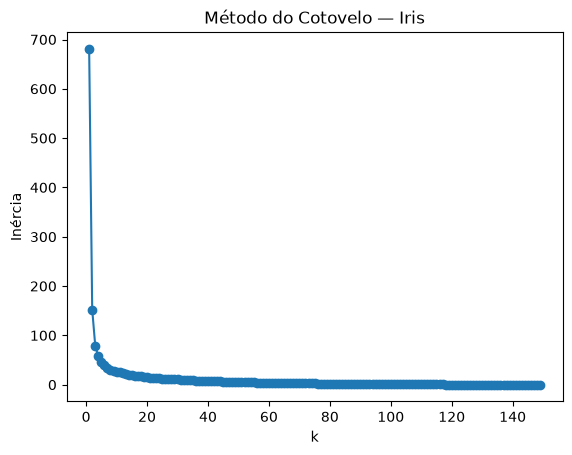

In [21]:
inercias=[]
valores_iris = range(1, 150)

for k in valores_iris:
    kmeans = KMeans(
        random_state=42,
        n_init=10,
        n_clusters=k
    )
    kmeans.fit(x)
    inercias.append(kmeans.inertia_)

plt.plot(valores_iris, inercias, marker="o")
plt.xlabel("k")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo — Iris")
plt.show()

In [22]:
for c, centro in enumerate(kmeans.cluster_centers_):
    print(f"Cluster:{c}")
    print(centro)
    print()

Cluster:0
[6.3 3.3 4.7 1.6]

Cluster:1
[4.9 3.6 1.4 0.1]

Cluster:2
[6.7 3.3 5.7 2.5]

Cluster:3
[5.5 2.5 4.  1.3]

Cluster:4
[7.7 2.8 6.7 2. ]

Cluster:5
[5.8 2.7 5.1 1.9]

Cluster:6
[4.4 2.9 1.4 0.2]

Cluster:7
[4.9 2.4 3.3 1. ]

Cluster:8
[6.3 2.8 5.1 1.5]

Cluster:9
[6.4 2.8 5.6 2.1]

Cluster:10
[5.7 3.8 1.7 0.3]

Cluster:11
[7.2 3.2 6.  1.8]

Cluster:12
[6.6 2.9 4.6 1.3]

Cluster:13
[5.7 2.8 4.5 1.3]

Cluster:14
[7.7 3.8 6.7 2.2]

Cluster:15
[4.9 3.1 1.5 0.2]

Cluster:16
[6.4 3.2 5.3 2.3]

Cluster:17
[5.8 2.7 3.9 1.2]

Cluster:18
[6.2 2.2 4.5 1.5]

Cluster:19
[5.1 3.7 1.5 0.4]

Cluster:20
[7.2 3.6 6.1 2.5]

Cluster:21
[5.4 3.7 1.5 0.2]

Cluster:22
[6.  3.  4.8 1.8]

Cluster:23
[4.9 2.5 4.5 1.7]

Cluster:24
[6.9 3.1 4.9 1.5]

Cluster:25
[5.7 2.9 4.2 1.3]

Cluster:26
[6.9 3.1 5.4 2.1]

Cluster:27
[5.1 3.4 1.5 0.2]

Cluster:28
[5.7 4.4 1.5 0.4]

Cluster:29
[7.7 3.  6.1 2.3]

Cluster:30
[6.2 2.9 4.3 1.3]

Cluster:31
[4.5 2.3 1.3 0.3]

Cluster:32
[6.1 2.9 4.7 1.4]

Cluster:33
[6.3 2.7 

## Método da Silhueta

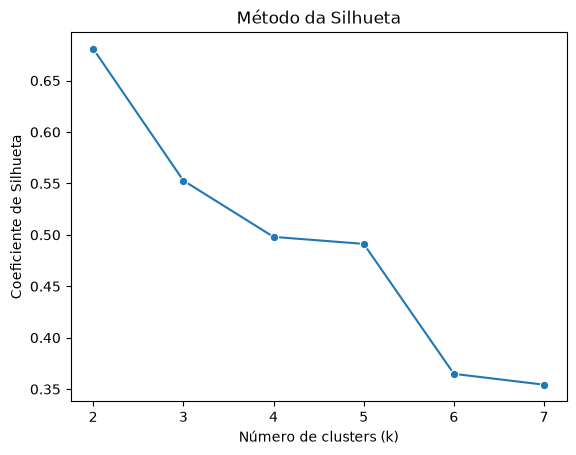

In [25]:
silhuetas = []
possibiliddes = range(2, 8)

for k in possibiliddes:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    kmeans.fit(x)
    score = silhouette_score(x, kmeans.labels_)
    silhuetas.append(score)

sns.lineplot(x=possibiliddes, y=silhuetas, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhueta")
plt.title("Método da Silhueta")
plt.show()

In [26]:


# Monta o DataFrame com os rótulos reais
df_comparacao = pd.DataFrame(x, columns=iris.feature_names)
df_comparacao["especie_real"] = iris.target

# Cenário k=2 (sugerido pela silhueta)
kmeans_k2 = KMeans(n_clusters=2, n_init=10, random_state=42)
df_comparacao["cluster_k2"] = kmeans_k2.fit_predict(x)

# Cenário k=3 (conhecimento de domínio: 3 espécies reais)
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
df_comparacao["cluster_k3"] = kmeans_k3.fit_predict(x)

# Tabelas cruzadas: linhas = espécie real, colunas = cluster encontrado
print("k=2 (silhueta):")
print(pd.crosstab(df_comparacao["especie_real"], df_comparacao["cluster_k2"]))

print("\nk=3 (domínio):")
print(pd.crosstab(df_comparacao["especie_real"], df_comparacao["cluster_k3"]))

k=2 (silhueta):
cluster_k2     0   1
especie_real        
0              0  50
1             47   3
2             50   0

k=3 (domínio):
cluster_k3     0   1   2
especie_real            
0              0  50   0
1             48   0   2
2             14   0  36


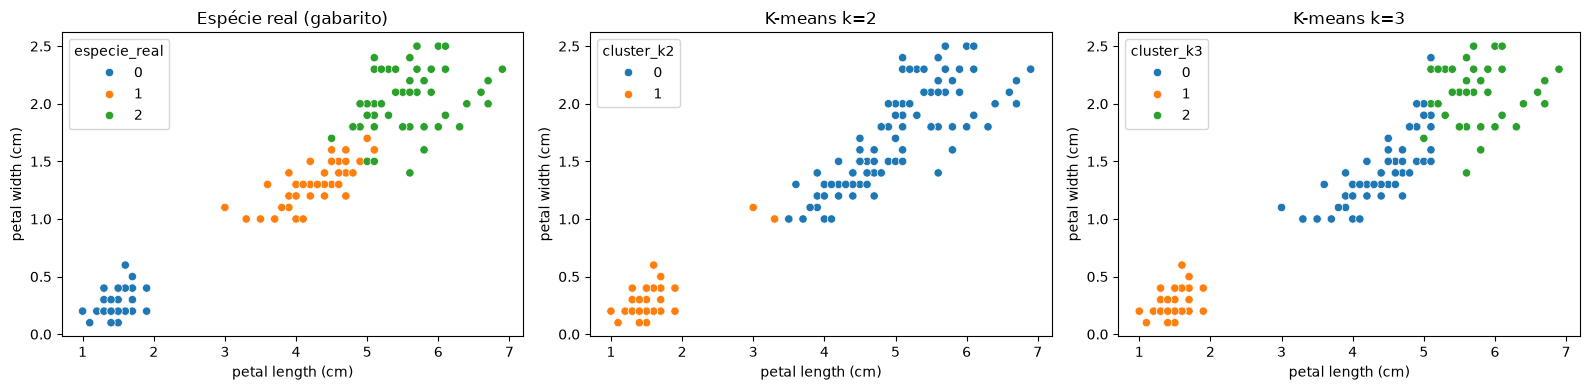

In [27]:


fig, eixos = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(data=df_comparacao, x="petal length (cm)", y="petal width (cm)",
                 hue="especie_real", palette="tab10", ax=eixos[0])
eixos[0].set_title("Espécie real (gabarito)")

sns.scatterplot(data=df_comparacao, x="petal length (cm)", y="petal width (cm)",
                 hue="cluster_k2", palette="tab10", ax=eixos[1])
eixos[1].set_title("K-means k=2")

sns.scatterplot(data=df_comparacao, x="petal length (cm)", y="petal width (cm)",
                 hue="cluster_k3", palette="tab10", ax=eixos[2])
eixos[2].set_title("K-means k=3")

plt.tight_layout()
plt.show()